In [2]:
GENERATED_DATA_PATH =  "./2_gen_mbj_bandgap/material_generated_samples_database_added_tr_check_added.csv"

In [54]:
import pandas as pd 
from datasets import load_dataset
import re
from upsetplot import UpSet
from collections import Counter
import numpy as np
df_gen = pd.read_csv(GENERATED_DATA_PATH)

In [7]:
df_gen.head()

,prompt,response,formula,expected_prop_val,after_alignn_prop_val,gen_material_str,gen_material_cif,Alexandria,Alexandria_id,MC3D,MC3D_id,OQMD,OQMD_id,JARVIS,JARVIS_id,MaterialsProject,MaterialsProject_id,Match_Found,Matched_Formula
0,Below is a description of a superconductor mat...,Below is a description of a superconductor mat...,SiH,3.711,NaN,3.9 3.9 5.0\n90 90 120\nSi\n0.33 0.67 0.93\nSi...,# generated using pymatgen\ndata_SiH\n_symmetr...,1.0,agm002086366,1.0,50707.0,11.0,4067700.0,2.0,dft_2d_JVASP-6808,1.0,mp-29803,True,SiH
1,Below is a description of a superconductor mat...,['Below is a description of a superconductor m...,HO,3.114,NaN,3.3 3.3 3.3\n90 90 90\nH\n0.00 0.00 0.00\nH\n0...,# generated using pymatgen\ndata_H2O2\n_symmet...,NaN,NaN,2.0,4687.0,8.0,4384824.0,8.0,dft_3d_JVASP-12577,2.0,mp-23939,True,HO
2,Below is a description of a superconductor mat...,['Below is a description of a superconductor m...,HC,3.811,NaN,3.7 3.7 3.7\n109 109 109\nH\n0.39 0.00 0.50\nH...,# generated using pymatgen\ndata_HC\n_symmetry...,2.0,agm003163144,2.0,232425.0,12.0,4482003.0,13.0,dft_3d_JVASP-101785,4.0,mp-995197,True,HC
3,Below is a description of a superconductor mat...,['Below is a description of a superconductor m...,HN,4.062,NaN,3.4 3.4 3.4\n109 109 108\nH\n0.75 0.75 -0.00\n...,# generated using pymatgen\ndata_HN\n_symmetry...,1.0,agm003240882,3.0,278619.0,13.0,4468545.0,5.0,dft_3d_JVASP-134971,4.0,mp-720515,NaN,NaN
4,Below is a description of a superconductor mat...,['Below is a description of a superconductor m...,AlH,3.261,NaN,3.6 3.6 5.1\n90 90 90\nAl\n0.50 0.50 0.39\nAl\...,# generated using pymatgen\ndata_AlH\n_symmetr...,NaN,NaN,NaN,NaN,8.0,4480989.0,3.0,dft_3d_JVASP-139255,NaN,NaN,True,AlH


In [52]:
colums = ["Alexandria", "MC3D", "OQMD", "JARVIS", "MaterialsProject","Match_Found"]
db_data = df_gen[colums]
db_data['Match_Found'] = db_data['Match_Found'].map({True: 1, np.nan: 0})
db_data

/tmp/ipykernel_1487304/2427494498.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  db_data['Match_Found'] = db_data['Match_Found'].map({True: 1, np.nan: 0})


,Alexandria,MC3D,OQMD,JARVIS,MaterialsProject,Match_Found
0,1.0,1.0,11.0,2.0,1.0,1
1,NaN,2.0,8.0,8.0,2.0,1
2,2.0,2.0,12.0,13.0,4.0,1
3,1.0,3.0,13.0,5.0,4.0,0
4,NaN,NaN,8.0,3.0,NaN,1
...,...,...,...,...,...,...
18895,NaN,NaN,NaN,NaN,NaN,0
18896,NaN,NaN,NaN,NaN,NaN,0
18897,NaN,NaN,NaN,NaN,NaN,0
18898,NaN,NaN,NaN,NaN,NaN,0


/home/jipengsun/.conda/envs/llm/lib/python3.10/site-packages/upsetplot/data.py:385: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df.fillna(False, inplace=True)
/home/jipengsun/.conda/envs/llm/lib/python3.10/site-packages/upsetplot/plotting.py:795: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  styles["linewidth

<Figure size 1600x1200 with 0 Axes>

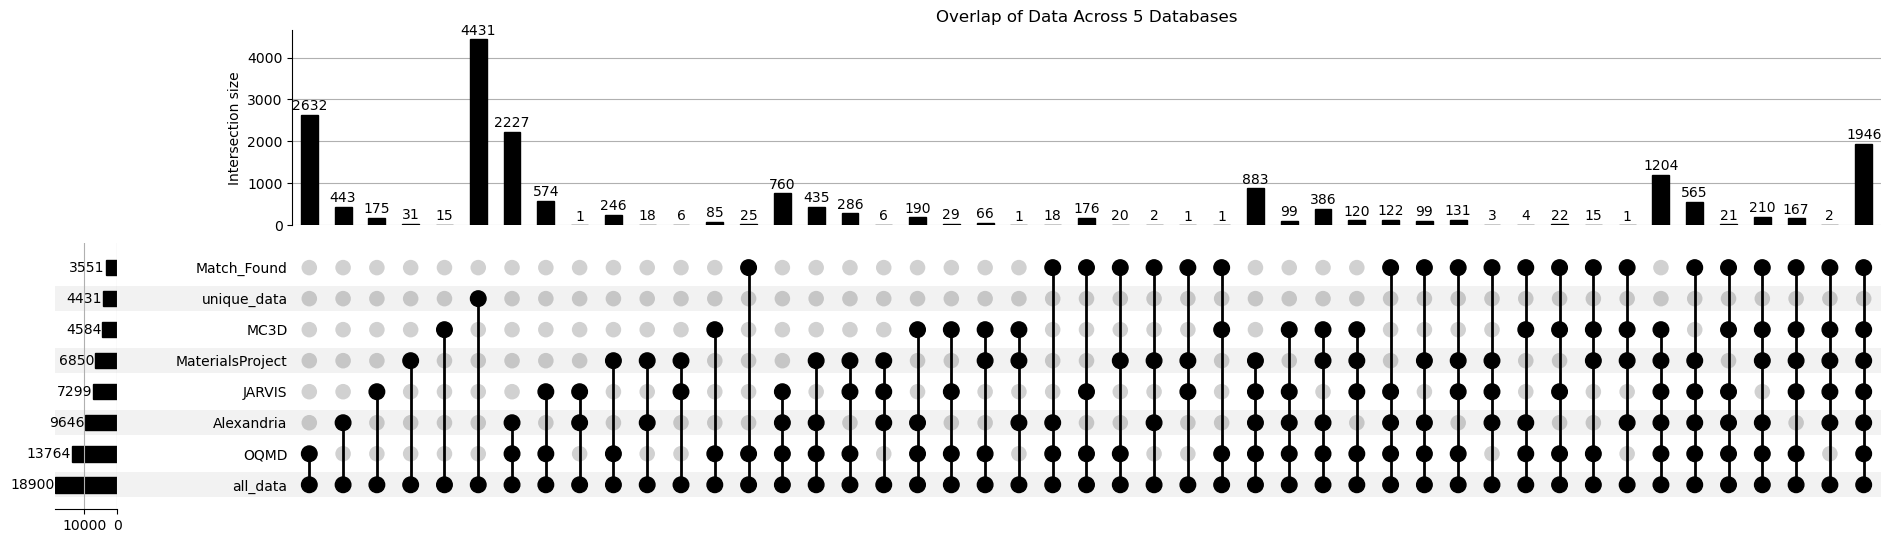

In [107]:
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
from upsetplot import UpSet, from_contents

idx_dict = {col: db_data.index[db_data[col] > 0].tolist() for col in db_data.columns}

all_data = df_gen.index.tolist()

all_data_set = set(all_data)  # Convert all_data to a set
idx_dict_values_set = set(sum(idx_dict.values(), []))  # Flatten and convert idx_dict values to a set

idx_dict['all_data'] = all_data
idx_dict['unique_data'] = list(all_data_set - idx_dict_values_set)


# UpSet Plot (better for 3+ sets)
upset_data = from_contents(idx_dict)



plt.figure(figsize=(16, 12))
UpSet(upset_data, show_counts=True).plot()
plt.title("Overlap of Data Across 5 Databases")
plt.show()


In [114]:
df_unique = df_gen.loc[sorted(idx_dict['unique_data'])]
df_unique.to_csv(f"./2_gen_mbj_bandgap/material_generated_unique.csv", index=False)

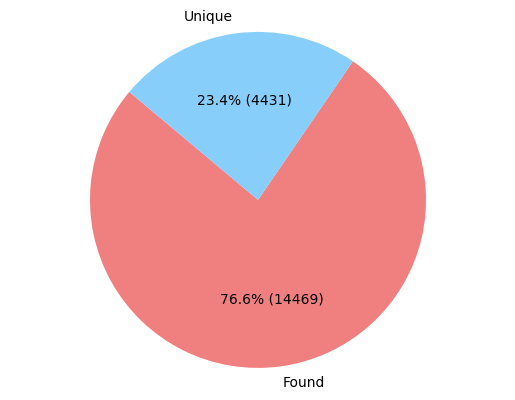

In [128]:
import matplotlib.pyplot as plt

# Data to plot
labels = ['Found','Unique']

sizes = [len(idx_dict_values_set), len(list(all_data_set - idx_dict_values_set))]
colors = ['lightcoral', 'lightskyblue']

# Create a pie chart
plt.pie(sizes, labels=labels, colors=colors, startangle=140, 
        autopct=lambda pct: f'{pct:.1f}% ({round(pct/100.*sum(sizes))})')

# Equal aspect ratio ensures that pie chart is drawn as a circle.
plt.axis('equal')

# Display the chart
plt.show()

In [115]:
#Test Data 